In [2]:
import yfinance as yf
import os

# Define the file path for our data
DATA_FILE = 'SPY_data.csv'

# Check if the data file already exists
if not os.path.exists(DATA_FILE):
    print(f"Data file not found. Downloading SPY data...")
    # Download historical data for SPY from 2000 to today
    data = yf.download('SPY', start='2000-01-01')
    # Save it to a CSV file
    data.to_csv(DATA_FILE)
    print(f"Data saved to {DATA_FILE}")
else:
    print(f"Found existing data file: {DATA_FILE}")

# Now, the rest of your code can run because the file is guaranteed to exist
# in the same folder as your notebook.
# ... (the rest of your script follows) ...
# df = load_data("SPY_data.csv")

Found existing data file: SPY_data.csv


Found existing data file: SPY_data.csv
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Hyperparameters Found:
{'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}

--- Performance Report ---
Total Return:       4.72%
Annualized Return:  5.01%
Annualized Vol:     7.79%
Sharpe Ratio:       0.64
Max Drawdown:       -8.63%
--------------------------



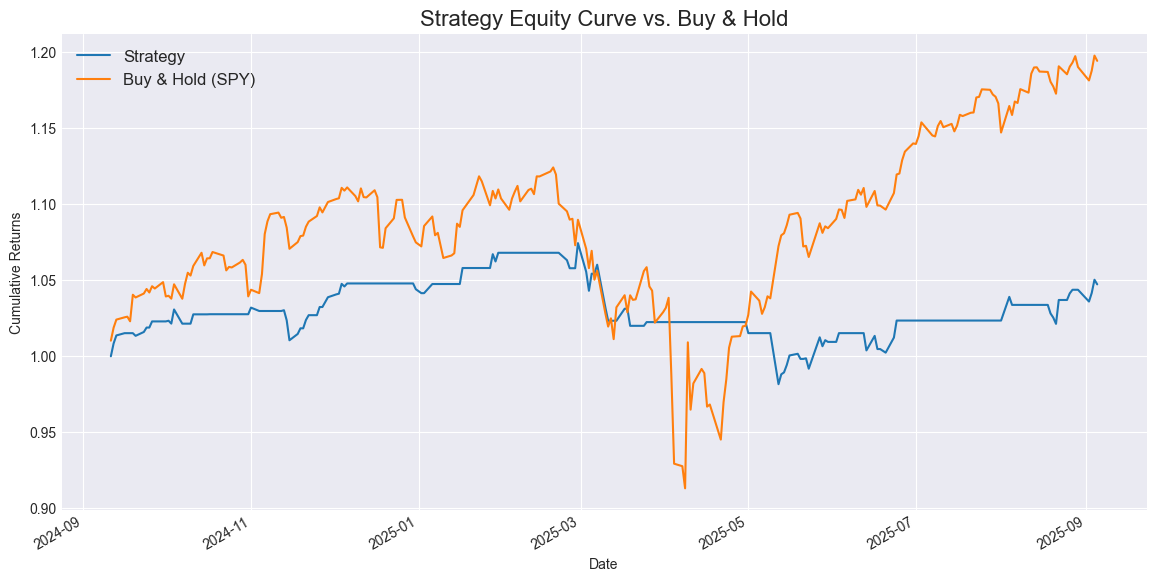

--- Classification Report ---
              precision    recall  f1-score   support

        Bear       0.33      0.04      0.07        24
        Bull       0.28      0.31      0.29        72
    Sideways       0.63      0.69      0.66       151

    accuracy                           0.51       247
   macro avg       0.41      0.35      0.34       247
weighted avg       0.50      0.51      0.49       247



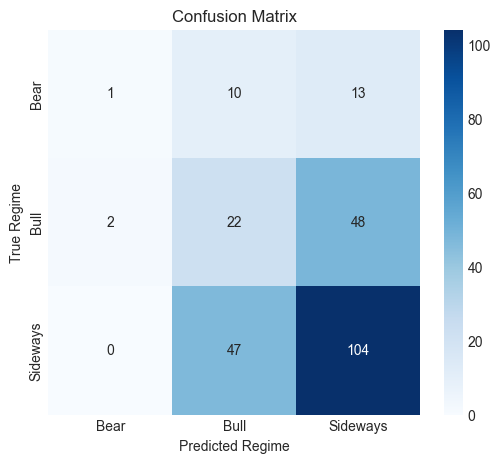

C:\Users\Admin\AppData\Local\Temp\ipykernel_12312\2741894627.py:233: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis', ax=ax)


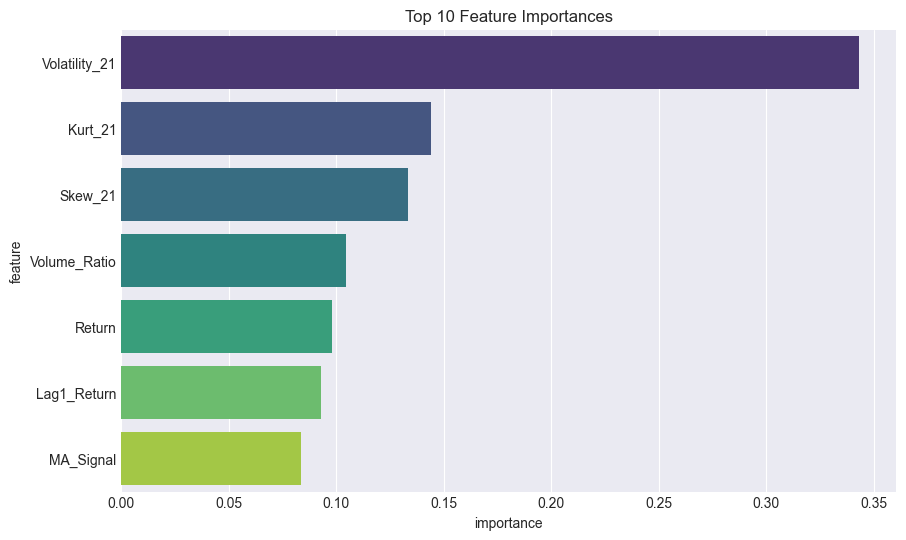

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os


from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix


def download_data_if_needed(ticker='SPY', start_date='2000-01-01', file_path='SPY_data.csv'):
    """
    Checks if the data file exists. If not, downloads historical data from Yahoo Finance.
    """
    if os.path.exists(file_path):
        print(f"Found existing data file: {file_path}")
    else:
        print(f"Data file not found. Downloading {ticker} data from Yahoo Finance...")
        try:
            data = yf.download(ticker, start=start_date)
            # Standardize column names to be consistent (e.g., 'Adj Close' -> 'Adj_Close')
            data.columns = [col.replace(' ', '_') for col in data.columns]
            data.to_csv(file_path)
            print(f"Data for {ticker} saved successfully to {file_path}")
        except Exception as e:
            print(f"Failed to download data: {e}")
            return None
    return file_path

def load_data(path):
    """
    Loads data from a CSV file and ensures numeric columns are correctly typed.
    """
    df = pd.read_csv(path, parse_dates=['Date'], index_col='Date')
    df = df.sort_index()

    # --- THE FIX IS HERE ---
    # Explicitly convert OHLCV columns to numeric, coercing errors to NaN.
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    # -----------------------
    
    # Use 'Adj_Close' for calculations as it accounts for dividends and splits
    if 'Adj_Close' in df.columns:
        df['Close'] = df['Adj_Close']
        
    # Drop any rows that have NaN values in critical columns after coercion
    df.dropna(subset=['Close', 'Volume'], inplace=True)
    
    return df



def feature_engineering(df):
    """
    Creates predictive features for the model.
    """
    df['Return'] = df['Close'].pct_change()
    df['MA_50']  = df['Close'].rolling(50).mean()
    df['MA_200'] = df['Close'].rolling(200).mean()
    df['MA_Signal'] = (df['MA_50'] > df['MA_200']).astype(int)

    window = 21 # Approximately one trading month
    df['Volatility_21'] = df['Return'].rolling(window).std() * np.sqrt(252)
    df['Skew_21']       = df['Return'].rolling(window).skew()
    df['Kurt_21']       = df['Return'].rolling(window).kurt()
    df['Lag1_Return']   = df['Return'].shift(1)
    df['Volume_Ratio']  = df['Volume'] / df['Volume'].rolling(window).mean()

    return df



def create_labels(df, window=21, return_thresh=0.03, vol_thresh=0.20):
    """
    Creates the target variable (market regime) based on future market behavior.
    """
    df['Future_Return'] = df['Close'].shift(-window) / df['Close'] - 1
    df['Future_Volatility'] = df['Return'].shift(-window).rolling(window).std() * np.sqrt(252)

    df['Regime'] = np.where(
        (df['Future_Return'] > return_thresh) & (df['Future_Volatility'] < vol_thresh), 'Bull',
        np.where(
            (df['Future_Return'] < -return_thresh) & (df['Future_Volatility'] > vol_thresh), 'Bear',
            'Sideways'
        )
    )
    return df



def train_test_split_time(df, features, label, train_frac=0.8):
    """
    Splits the data into training and testing sets based on time.
    """
    df_clean = df.dropna(subset=features + [label])
    split_idx = int(len(df_clean) * train_frac)
    
    X_train = df_clean[features].iloc[:split_idx]
    y_train = df_clean[label].iloc[:split_idx]
    X_test  = df_clean[features].iloc[split_idx:]
    y_test  = df_clean[label].iloc[split_idx:]
    
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train):
    """
    Trains a RandomForest model using a pipeline and GridSearchCV for hyperparameter tuning.
    """
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])

    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 10],
        'clf__min_samples_leaf': [5, 10]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    print("\nBest Hyperparameters Found:")
    print(grid_search.best_params_)
    return grid_search.best_estimator_

def detect_anomalies(X_train, X_test, contamination=0.01):
    """
    Uses an IsolationForest to flag anomalous days.
    """
    iso = IsolationForest(contamination=contamination, random_state=42)
    iso.fit(X_train)
    return iso.predict(X_test) # Returns 1 for normal, -1 for anomaly

def backtest_strategy(df, signals):
    """
    Performs a vectorized backtest of the trading signals.
    """
    df_bt = df.copy()
    df_bt['Signal'] = signals.shift(1).fillna(0) # IMPORTANT: Trade on the next day's open
    
    df_bt['Strategy_Return'] = df_bt['Signal'] * df_bt['Return']
    df_bt['Cumulative_Strategy'] = (1 + df_bt['Strategy_Return']).cumprod()
    df_bt['Cumulative_Market'] = (1 + df_bt['Return']).cumprod()
    
    return df_bt



def generate_performance_report(df_backtest):
    """
    Calculates and prints key performance metrics.
    """
    returns = df_backtest['Strategy_Return'].dropna()
    
    total_return = df_backtest['Cumulative_Strategy'].iloc[-1] - 1
    annualized_return = returns.mean() * 252
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
    
    rolling_max = df_backtest['Cumulative_Strategy'].cummax()
    drawdown = (df_backtest['Cumulative_Strategy'] - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    print("\n--- Performance Report ---")
    print(f"Total Return:       {total_return:.2%}")
    print(f"Annualized Return:  {annualized_return:.2%}")
    print(f"Annualized Vol:     {annualized_volatility:.2%}")
    print(f"Sharpe Ratio:       {sharpe_ratio:.2f}")
    print(f"Max Drawdown:       {max_drawdown:.2%}")
    print("--------------------------\n")

    # Plot Equity Curves
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(14, 7))
    df_backtest['Cumulative_Strategy'].plot(ax=ax, label='Strategy')
    df_backtest['Cumulative_Market'].plot(ax=ax, label='Buy & Hold (SPY)')
    ax.set_title('Strategy Equity Curve vs. Buy & Hold', fontsize=16)
    ax.set_ylabel('Cumulative Returns')
    ax.legend(fontsize=12)
    plt.show()

def generate_classification_plots(y_true, y_pred, model, feature_names):
    """
    Generates confusion matrix and feature importance plots.
    """
    labels = sorted(y_true.unique())
    
    # Classification Report
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted Regime')
    ax.set_ylabel('True Regime')
    plt.show()

    # Feature Importances
    importances = model.named_steps['clf'].feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis', ax=ax)
    ax.set_title('Top 10 Feature Importances')
    plt.show()


if __name__ == "__main__":
    # --- 1. Setup & Data Loading ---
    DATA_FILE_PATH = download_data_if_needed(ticker='SPY')
    df_raw = load_data(DATA_FILE_PATH)

    # --- 2. Feature & Label Engineering ---
    df_features = feature_engineering(df_raw)
    df_labeled = create_labels(df_features)

    # --- 3. Modeling ---
    FEATURE_COLS = ['MA_Signal', 'Return', 'Volatility_21', 'Skew_21', 'Kurt_21', 'Lag1_Return', 'Volume_Ratio']
    LABEL_COL = 'Regime'
    
    X_train, X_test, y_train, y_test = train_test_split_time(df_labeled, FEATURE_COLS, LABEL_COL)
    
    model = train_model(X_train, y_train)

    # --- 4. Prediction & Signal Generation ---
    anomaly_flags = detect_anomalies(X_train, X_test)
    predictions = pd.Series(model.predict(X_test), index=X_test.index)
    predictions[anomaly_flags == -1] = 'Sideways' # Neutralize signals on anomalous days

    signal_map = {'Bull': 1, 'Bear': -1, 'Sideways': 0}
    signals = predictions.map(signal_map)

    # --- 5. Backtesting & Reporting ---
    df_backtest = backtest_strategy(df_labeled.loc[X_test.index], signals)
    
    generate_performance_report(df_backtest)
    generate_classification_plots(y_test, predictions, model, FEATURE_COLS)

🚀 Starting Trading Signal Generator...
📦 Loading required libraries...



🚀 AI-POWERED TRADING SIGNAL GENERATOR
📊 Analyze ANY stock with Machine Learning-based predictions
💡 Get Buy/Sell/Hold signals based on market regime detection

📋 SELECT A STOCK TO ANALYZE:


📈 Popular US Stocks
----------------------------------------
  [ 1] SPY             - S&P 500 ETF - Tracks top 500 US companies
  [ 2] AAPL            - Apple Inc. - iPhone, Mac, iPad maker
  [ 3] MSFT            - Microsoft - Windows, Office, Azure
  [ 4] GOOGL           - Google/Alphabet - Search, YouTube, Android
  [ 5] TSLA            - Tesla - Electric vehicles & energy
  [ 6] NVDA            - NVIDIA - AI chips & graphics cards
  [ 7] META            - Meta/Facebook - Social media giant
  [ 8] AMZN            - Amazon - E-commerce & cloud computing

💼 Indian Stocks (NSE)
----------------------------------------
  [ 9] RELIANCE.NS     - Reliance Industries - Oil, Telecom, Retail
  [10] TCS.NS          - Tata Consultancy 


👉 Enter your choice (number, C, or Q):  C
📝 Enter stock symbol (e.g., GOOGL, RELIANCE.NS):  GOOGL
📝 Enter stock name/description (optional):  Google/Alphabet - Search, YouTube, Android



⚙️ ANALYSIS PARAMETERS:
----------------------------------------

📅 Select time period for analysis:
  [1] 1 Year   (Good for short-term trends)
  [2] 2 Years  (Balanced view)
  [3] 3 Years  (Includes COVID period)
  [4] 5 Years  (Long-term analysis) [DEFAULT]



👉 Enter choice (1-4) or press Enter for default:  2



⚠️ Select risk tolerance:
  [1] Conservative (More Sideways signals)
  [2] Moderate     (Balanced) [DEFAULT]
  [3] Aggressive   (More Buy/Sell signals)



👉 Enter choice (1-3) or press Enter for default:  2





🔍 ANALYSIS IN PROGRESS

📊 Stock:        GOOGL - Google/Alphabet - Search, YouTube, Android
📅 Time Period:  2 years
⚠️  Risk Level:   Moderate


⏳ Please wait while we analyze the data...

📥 Downloading GOOGL data...
✅ Downloaded 501 days of data
🔧 Creating technical indicators...
✅ Created 23 technical indicators
🏷️ Creating regime labels (moderate risk)...
🤖 Training AI model...
✅ Model trained successfully!



📊 ANALYSIS RESULTS FOR GOOGL

🏢 Company: Google/Alphabet - Search, YouTube, Android
📅 Test Period: 2025-04-25 to 2025-09-18
📈 Days Analyzed: 101

💰 PERFORMANCE COMPARISON

Metric                        AI Strategy      Buy & Hold      Difference
----------------------------------------------------------------------
Total Return                      -11.99%          57.36%         -69.34%
Annual Return                     -30.60%         117.59%        -148.19%
Sharpe Ratio                       -1.98             N/A                
Max Drawdown                      -11.99%  

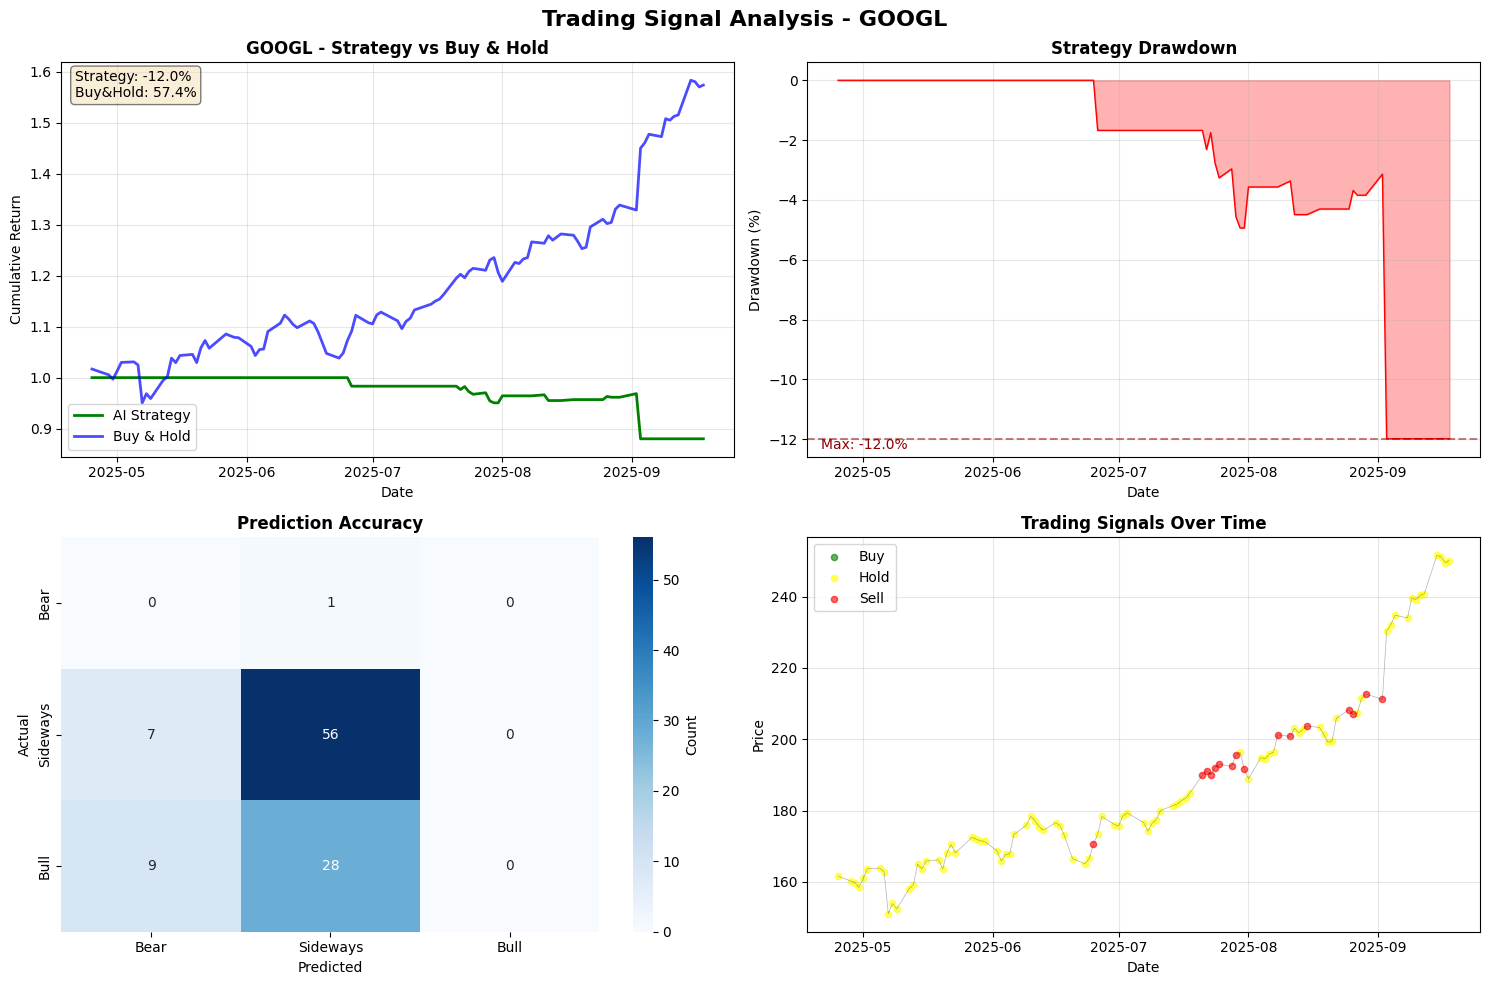

In [ ]:


import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix



STOCK_PRESETS = {
    "📈 Popular US Stocks": {
        "1": ("SPY", "S&P 500 ETF - Tracks top 500 US companies"),
        "2": ("AAPL", "Apple Inc. - iPhone, Mac, iPad maker"),
        "3": ("MSFT", "Microsoft - Windows, Office, Azure"),
        "4": ("GOOGL", "Google/Alphabet - Search, YouTube, Android"),
        "5": ("TSLA", "Tesla - Electric vehicles & energy"),
        "6": ("NVDA", "NVIDIA - AI chips & graphics cards"),
        "7": ("META", "Meta/Facebook - Social media giant"),
        "8": ("AMZN", "Amazon - E-commerce & cloud computing"),
    },
    "💼 Indian Stocks (NSE)": {
        "9": ("RELIANCE.NS", "Reliance Industries - Oil, Telecom, Retail"),
        "10": ("TCS.NS", "Tata Consultancy Services - IT giant"),
        "11": ("HDFCBANK.NS", "HDFC Bank - Largest private bank"),
        "12": ("INFY.NS", "Infosys - IT services & consulting"),
        "13": ("ICICIBANK.NS", "ICICI Bank - Private sector bank"),
        "14": ("WIPRO.NS", "Wipro - IT services company"),
        "15": ("BHARTIARTL.NS", "Bharti Airtel - Telecom leader"),
        "16": ("ITC.NS", "ITC - Cigarettes, FMCG, Hotels"),
    },
    "🏦 Sector ETFs": {
        "17": ("QQQ", "Nasdaq 100 - Tech-heavy index"),
        "18": ("XLF", "Financial Sector ETF - Banks & Insurance"),
        "19": ("XLE", "Energy Sector ETF - Oil & Gas companies"),
        "20": ("GLD", "Gold ETF - Tracks gold prices"),
    },
    "🪙 Cryptocurrencies": {
        "21": ("BTC-USD", "Bitcoin - Largest cryptocurrency"),
        "22": ("ETH-USD", "Ethereum - Smart contracts platform"),
    }
}



def clear_screen():
    """Clear screen for better UI"""
    print("\n" * 2)

def print_header():
    """Print application header"""
    print("="*80)
    print("🚀 AI-POWERED TRADING SIGNAL GENERATOR")
    print("="*80)
    print("📊 Analyze ANY stock with Machine Learning-based predictions")
    print("💡 Get Buy/Sell/Hold signals based on market regime detection")
    print("="*80)

def get_user_stock_selection():
    """Interactive menu for stock selection"""
    clear_screen()
    print_header()
    
    print("\n📋 SELECT A STOCK TO ANALYZE:\n")
    
    # Display all categories and stocks
    for category, stocks in STOCK_PRESETS.items():
        print(f"\n{category}")
        print("-" * 40)
        for key, (symbol, description) in stocks.items():
            print(f"  [{key:>2}] {symbol:<15} - {description}")
    
    print("\n" + "="*80)
    print("🔧 CUSTOM OPTIONS:")
    print("-" * 40)
    print("  [C]  Enter custom stock symbol")
    print("  [Q]  Quit application")
    print("="*80)
    
    # Get user input
    while True:
        choice = input("\n👉 Enter your choice (number, C, or Q): ").strip().upper()
        
        if choice == 'Q':
            print("\n👋 Thank you for using Trading Signal Generator!")
            return None, None
        
        if choice == 'C':
            custom_symbol = input("📝 Enter stock symbol (e.g., GOOGL, RELIANCE.NS): ").strip().upper()
            custom_name = input("📝 Enter stock name/description (optional): ").strip()
            if not custom_name:
                custom_name = custom_symbol
            return custom_symbol, custom_name
        
        # Check if valid number selection
        for category, stocks in STOCK_PRESETS.items():
            if choice in stocks:
                symbol, description = stocks[choice]
                return symbol, description
        
        print("❌ Invalid choice. Please try again.")

def get_analysis_parameters():
    """Get additional parameters from user"""
    print("\n⚙️ ANALYSIS PARAMETERS:")
    print("-" * 40)
    
    # Time period selection
    print("\n📅 Select time period for analysis:")
    print("  [1] 1 Year   (Good for short-term trends)")
    print("  [2] 2 Years  (Balanced view)")
    print("  [3] 3 Years  (Includes COVID period)")
    print("  [4] 5 Years  (Long-term analysis) [DEFAULT]")
    
    period_choice = input("\n👉 Enter choice (1-4) or press Enter for default: ").strip()
    
    period_map = {"1": 1, "2": 2, "3": 3, "4": 5}
    years = period_map.get(period_choice, 5)
    
    # Risk level selection
    print("\n⚠️ Select risk tolerance:")
    print("  [1] Conservative (More Sideways signals)")
    print("  [2] Moderate     (Balanced) [DEFAULT]")
    print("  [3] Aggressive   (More Buy/Sell signals)")
    
    risk_choice = input("\n👉 Enter choice (1-3) or press Enter for default: ").strip()
    
    risk_map = {"1": "conservative", "2": "moderate", "3": "aggressive"}
    risk_level = risk_map.get(risk_choice, "moderate")
    
    return years, risk_level

def display_analysis_summary(symbol, name, years, risk_level):
    """Display what's being analyzed"""
    clear_screen()
    print("="*80)
    print("🔍 ANALYSIS IN PROGRESS")
    print("="*80)
    print(f"\n📊 Stock:        {symbol} - {name}")
    print(f"📅 Time Period:  {years} years")
    print(f"⚠️  Risk Level:   {risk_level.capitalize()}")
    print("\n" + "="*80)
    print("\n⏳ Please wait while we analyze the data...\n")



def download_stock_data(symbol, years=5):
    """Download stock data with error handling"""
    try:
        print(f"📥 Downloading {symbol} data...")
        
        end_date = datetime.now()
        start_date = end_date - timedelta(days=years*365)
        
        ticker = yf.Ticker(symbol)
        data = ticker.history(start=start_date, end=end_date, interval="1d")
        
        if data.empty:
            print(f"❌ No data found for {symbol}")
            return None
        
        # Clean data
        data = data[['Open', 'High', 'Low', 'Close', 'Volume']]
        for col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
        
        data = data.dropna()
        data.reset_index(inplace=True)
        
        print(f"✅ Downloaded {len(data)} days of data")
        return data
        
    except Exception as e:
        print(f"❌ Error downloading data: {str(e)}")
        return None

def calculate_rsi(prices, period=14):
    """Calculate RSI indicator"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def feature_engineering(df):
    """Create technical features"""
    print("🔧 Creating technical indicators...")
    
    df = df.copy()
    
    if 'Date' in df.columns:
        df.set_index('Date', inplace=True)
    
    # Core features
    df['Return'] = df['Close'].pct_change()
    
    # Moving averages
    df['MA_20'] = df['Close'].rolling(window=20, min_periods=1).mean()
    df['MA_50'] = df['Close'].rolling(window=50, min_periods=1).mean()
    df['MA_200'] = df['Close'].rolling(window=200, min_periods=1).mean()
    
    # Signals
    df['MA_Signal_Fast'] = (df['MA_20'] > df['MA_50']).astype(int)
    df['MA_Signal_Slow'] = (df['MA_50'] > df['MA_200']).astype(int)
    
    # Price ratios
    df['Price_to_MA20'] = (df['Close'] / df['MA_20']) - 1
    df['Price_to_MA50'] = (df['Close'] / df['MA_50']) - 1
    
    # Volatility
    df['Volatility'] = df['Return'].rolling(window=21, min_periods=1).std() * np.sqrt(252)
    df['Skewness'] = df['Return'].rolling(window=21, min_periods=3).skew()
    df['Kurtosis'] = df['Return'].rolling(window=21, min_periods=3).kurt()
    
    # Technical indicators
    df['RSI'] = calculate_rsi(df['Close'], 14)
    
    # Momentum
    df['Momentum_5'] = df['Close'].pct_change(periods=5)
    df['Momentum_10'] = df['Close'].pct_change(periods=10)
    df['Momentum_21'] = df['Close'].pct_change(periods=21)
    
    # Volume
    df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(window=20, min_periods=1).mean()
    
    # High-Low spread
    df['HL_Spread'] = (df['High'] - df['Low']) / df['Close']
    
    # Lagged features
    for lag in [1, 2, 5]:
        df[f'Return_Lag_{lag}'] = df['Return'].shift(lag)
        df[f'Volume_Ratio_Lag_{lag}'] = df['Volume_Ratio'].shift(lag)
    
    df = df.fillna(method='ffill').fillna(method='bfill')
    
    print(f"✅ Created {len(df.columns) - 5} technical indicators")
    return df

def create_regime_labels(df, risk_level="moderate", lookahead_days=21):
    """Create regime labels based on risk level"""
    print(f"🏷️ Creating regime labels ({risk_level} risk)...")
    
    df = df.copy()
    
    # Calculate future metrics
    df['Future_Return'] = df['Close'].shift(-lookahead_days) / df['Close'] - 1
    df['Future_Volatility'] = df['Return'].shift(-lookahead_days).rolling(
        window=lookahead_days, min_periods=1
    ).std() * np.sqrt(252)
    
    # Risk-based thresholds
    thresholds = {
        "conservative": {"bull": 0.05, "bear": -0.04, "vol_high": 0.15, "vol_low": 0.25},
        "moderate": {"bull": 0.03, "bear": -0.02, "vol_high": 0.15, "vol_low": 0.25},
        "aggressive": {"bull": 0.02, "bear": -0.01, "vol_high": 0.20, "vol_low": 0.30}
    }
    
    thresh = thresholds[risk_level]
    
    # Assign regimes
    df['Regime'] = 'Sideways'
    
    bull_mask = (df['Future_Return'] > thresh['bull']) & (df['Future_Volatility'] < thresh['vol_low'])
    df.loc[bull_mask, 'Regime'] = 'Bull'
    
    bear_mask = (df['Future_Return'] < thresh['bear']) & (df['Future_Volatility'] > thresh['vol_high'])
    df.loc[bear_mask, 'Regime'] = 'Bear'
    
    return df

def train_and_predict(df, feature_cols):
    """Train model and make predictions"""
    print("🤖 Training AI model...")
    
    # Prepare data
    df_clean = df.dropna(subset=['Regime'])
    df_clean = df_clean.dropna(subset=feature_cols)
    
    # Split
    split_idx = int(len(df_clean) * 0.8)
    train_data = df_clean.iloc[:split_idx]
    test_data = df_clean.iloc[split_idx:]
    
    X_train = train_data[feature_cols].values
    y_train = train_data['Regime'].values
    X_test = test_data[feature_cols].values
    y_test = test_data['Regime'].values
    
    # Train model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    print(f"✅ Model trained successfully!")
    
    return pipeline, test_data.index, y_test, y_pred

def run_backtest(df, predictions, test_index):
    """Run trading backtest"""
    bt_df = df.loc[test_index].copy()
    
    bt_df['Prediction'] = predictions
    signal_map = {'Bull': 1, 'Bear': -1, 'Sideways': 0}
    bt_df['Signal'] = bt_df['Prediction'].map(signal_map)
    bt_df['Position'] = bt_df['Signal'].shift(1).fillna(0)
    
    bt_df['Strategy_Return'] = bt_df['Position'] * bt_df['Return']
    bt_df['Cum_Strategy'] = (1 + bt_df['Strategy_Return']).cumprod()
    bt_df['Cum_Market'] = (1 + bt_df['Return']).cumprod()
    
    return bt_df

def calculate_metrics(bt_df):
    """Calculate performance metrics"""
    strategy_returns = bt_df['Strategy_Return'].dropna()
    
    total_return = (bt_df['Cum_Strategy'].iloc[-1] - 1) * 100
    annual_return = strategy_returns.mean() * 252 * 100
    annual_vol = strategy_returns.std() * np.sqrt(252) * 100
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    cum_returns = bt_df['Cum_Strategy']
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min() * 100
    
    wins = (strategy_returns > 0).sum()
    total_trades = (strategy_returns != 0).sum()
    win_rate = (wins / total_trades * 100) if total_trades > 0 else 0
    
    # Buy & Hold metrics
    market_total_return = (bt_df['Cum_Market'].iloc[-1] - 1) * 100
    market_returns = bt_df['Return'].dropna()
    market_annual_return = market_returns.mean() * 252 * 100
    
    return {
        'Total Return': total_return,
        'Annual Return': annual_return,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Win Rate': win_rate,
        'Market Total Return': market_total_return,
        'Market Annual Return': market_annual_return,
        'Outperformance': total_return - market_total_return
    }

def display_results(symbol, name, bt_df, metrics, y_test, y_pred):
    """Display comprehensive results"""
    clear_screen()
    print("="*80)
    print(f"📊 ANALYSIS RESULTS FOR {symbol}")
    print("="*80)
    print(f"\n🏢 Company: {name}")
    print(f"📅 Test Period: {bt_df.index[0].date()} to {bt_df.index[-1].date()}")
    print(f"📈 Days Analyzed: {len(bt_df)}")
    
    # Performance comparison
    print("\n" + "="*80)
    print("💰 PERFORMANCE COMPARISON")
    print("="*80)
    
    print(f"\n{'Metric':<25} {'AI Strategy':>15} {'Buy & Hold':>15} {'Difference':>15}")
    print("-"*70)
    
    print(f"{'Total Return':<25} {metrics['Total Return']:>14.2f}% {metrics['Market Total Return']:>14.2f}% {metrics['Outperformance']:>14.2f}%")
    print(f"{'Annual Return':<25} {metrics['Annual Return']:>14.2f}% {metrics['Market Annual Return']:>14.2f}% {metrics['Annual Return']-metrics['Market Annual Return']:>14.2f}%")
    print(f"{'Sharpe Ratio':<25} {metrics['Sharpe Ratio']:>14.2f} {'N/A':>15} {'':>15}")
    print(f"{'Max Drawdown':<25} {metrics['Max Drawdown']:>14.2f}% {'N/A':>15} {'':>15}")
    print(f"{'Win Rate':<25} {metrics['Win Rate']:>14.2f}% {'N/A':>15} {'':>15}")
    
    # Trading signals
    print("\n" + "="*80)
    print("📈 TRADING SIGNAL SUMMARY")
    print("="*80)
    
    signal_counts = pd.Series(y_pred).value_counts()
    total_signals = len(y_pred)
    
    print(f"\n{'Signal Type':<15} {'Count':>10} {'Percentage':>15}")
    print("-"*40)
    for signal in ['Bull', 'Sideways', 'Bear']:
        if signal in signal_counts.index:
            count = signal_counts[signal]
            pct = (count / total_signals) * 100
            action = {'Bull': '(BUY)', 'Bear': '(SELL)', 'Sideways': '(HOLD)'}[signal]
            print(f"{signal:<8} {action:<7} {count:>10} {pct:>14.1f}%")
    
    # Current recommendation
    print("\n" + "="*80)
    print("🎯 CURRENT RECOMMENDATION")
    print("="*80)
    
    last_signal = y_pred[-1]
    last_date = bt_df.index[-1].date()
    
    signal_emoji = {'Bull': '🟢', 'Bear': '🔴', 'Sideways': '🟡'}
    signal_action = {'Bull': 'BUY', 'Bear': 'SELL', 'Sideways': 'HOLD'}
    
    print(f"\n  {signal_emoji[last_signal]} Latest Signal ({last_date}): {signal_action[last_signal]}")
    
    if last_signal == 'Bull':
        print("  💡 Recommendation: Consider buying - Market shows bullish signs")
    elif last_signal == 'Bear':
        print("  💡 Recommendation: Consider selling or staying out - Market shows bearish signs")
    else:
        print("  💡 Recommendation: Hold current position - Market direction unclear")
    
    # Plot results
    plot_interactive_results(bt_df, y_test, y_pred, metrics, symbol)

def plot_interactive_results(bt_df, y_test, y_pred, metrics, symbol):
    """Create comprehensive visualization"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Equity curves
    ax1 = axes[0, 0]
    ax1.plot(bt_df.index, bt_df['Cum_Strategy'], label='AI Strategy', linewidth=2, color='green')
    ax1.plot(bt_df.index, bt_df['Cum_Market'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    ax1.set_title(f'{symbol} - Strategy vs Buy & Hold', fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add performance annotation
    ax1.text(0.02, 0.98, f"Strategy: {metrics['Total Return']:.1f}%\nBuy&Hold: {metrics['Market Total Return']:.1f}%",
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    cum_returns = bt_df['Cum_Strategy']
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max * 100
    ax2.fill_between(bt_df.index, drawdown, 0, color='red', alpha=0.3)
    ax2.plot(bt_df.index, drawdown, color='red', linewidth=1)
    ax2.set_title('Strategy Drawdown', fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=metrics['Max Drawdown'], color='darkred', linestyle='--', alpha=0.5)
    ax2.text(0.02, 0.02, f"Max: {metrics['Max Drawdown']:.1f}%",
             transform=ax2.transAxes, color='darkred')
    
    # 3. Confusion Matrix
    ax3 = axes[1, 0]
    cm = confusion_matrix(y_test, y_pred, labels=['Bear', 'Sideways', 'Bull'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bear', 'Sideways', 'Bull'],
                yticklabels=['Bear', 'Sideways', 'Bull'],
                ax=ax3, cbar_kws={'label': 'Count'})
    ax3.set_title('Prediction Accuracy', fontweight='bold')
    ax3.set_ylabel('Actual')
    ax3.set_xlabel('Predicted')
    
    # 4. Signal Distribution Over Time
    ax4 = axes[1, 1]
    signal_map = {'Bull': 1, 'Bear': -1, 'Sideways': 0}
    signals = pd.Series(y_pred, index=bt_df.index).map(signal_map)
    
    colors = {1: 'green', 0: 'yellow', -1: 'red'}
    for signal_val, color in colors.items():
        mask = signals == signal_val
        ax4.scatter(bt_df.index[mask], bt_df['Close'][mask], 
                   c=color, alpha=0.6, s=20,
                   label={'green': 'Buy', 'yellow': 'Hold', 'red': 'Sell'}[color])
    
    ax4.plot(bt_df.index, bt_df['Close'], color='black', alpha=0.3, linewidth=0.5)
    ax4.set_title('Trading Signals Over Time', fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Price')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Trading Signal Analysis - {symbol}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()



def main():
    """Main application loop"""
    while True:
        # Get stock selection
        symbol, name = get_user_stock_selection()
        
        if symbol is None:  # User chose to quit
            break
        
        # Get analysis parameters
        years, risk_level = get_analysis_parameters()
        
        # Display analysis summary
        display_analysis_summary(symbol, name, years, risk_level)
        
        try:
            # Download data
            data = download_stock_data(symbol, years)
            
            if data is None:
                print("\n❌ Failed to download data. Please try another stock.")
                input("\nPress Enter to continue...")
                continue
            
            # Run analysis
            data = feature_engineering(data)
            data = create_regime_labels(data, risk_level)
            
            # Define features
            feature_columns = [
                'MA_Signal_Fast', 'MA_Signal_Slow',
                'Price_to_MA20', 'Price_to_MA50',
                'Volatility', 'RSI',
                'Momentum_5', 'Momentum_10',
                'Volume_Ratio', 'HL_Spread',
                'Return_Lag_1', 'Return_Lag_2'
            ]
            
            # Train and predict
            model, test_index, y_test, y_pred = train_and_predict(data, feature_columns)
            
            # Backtest
            bt_df = run_backtest(data, y_pred, test_index)
            
            # Calculate metrics
            metrics = calculate_metrics(bt_df)
            
            # Display results
            display_results(symbol, name, bt_df, metrics, y_test, y_pred)
            
            # Ask if user wants to analyze another stock
            print("\n" + "="*80)
            another = input("\n🔄 Would you like to analyze another stock? (Y/N): ").strip().upper()
            
            if another != 'Y':
                print("\n👋 Thank you for using Trading Signal Generator!")
                print("💡 Remember: Always do your own research before making investment decisions!")
                break
                
        except Exception as e:
            print(f"\n❌ Error during analysis: {str(e)}")
            input("\nPress Enter to continue...")
            continue

if __name__ == "__main__":
    print("🚀 Starting Trading Signal Generator...")
    print("📦 Loading required libraries...")
    main()